In [1]:
import jax.numpy as jnp
from jax import random
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from src.utils import align_tracked_particle_across_layers
from src.jax_resnet.model import init_params

In [3]:
DATASET = "cifar10"  # or "mnist"

In [4]:
if DATASET == "mnist":
    from mnist_config import (
        d_in, d_out, seed, N, X_train, Y_train, X_test, Y_test, 
        tau, n_steps, lr_in, lr_out, q, batch_size, 
        last_particle_single_source, eval_every, ACTIVATION, num_repetitions, LOOP_SEED,
        BASE_SETTING_STR
        )
elif DATASET == "cifar10":
    from cifar10_config import (
        d_in, d_out, seed, N, X_train, Y_train, X_test, Y_test, 
        tau, n_steps, lr_in, lr_out, q, batch_size, 
        last_particle_single_source, eval_every, ACTIVATION, num_repetitions, LOOP_SEED,
        BASE_SETTING_STR
    )

/home/maass/pvc/dropout_and_ram_2026/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


(50000, 3072) (50000, 10) (10000, 3072) (10000, 10)


In [5]:
D = 10 if DATASET == "mnist" else 50

In [6]:
D, L, M = D, 128, 128

In [7]:
params0 = init_params(random.PRNGKey(seed + 44), d_in, d_out, D, L, M)
params0 = align_tracked_particle_across_layers(params0, particle_idx=-1)

In [8]:
import pickle

setting_str = f'L{L}_M{M}_D{D}' + BASE_SETTING_STR


# Export (serialize) to pickle
with open(f'data/{DATASET}/final_params_gd_{setting_str}.pkl', 'rb') as f:   # 'wb' = write binary
    final_params_gd = pickle.load(f)

with open(f'data/{DATASET}/histories_gd_{setting_str}.pkl', 'rb') as f:   # 'wb' = write binary
    histories_gd = pickle.load(f)

with open(f'data/{DATASET}/final_params_do_{setting_str}.pkl', 'rb') as f:   # 'wb' = write binary
    final_params_do = pickle.load(f)

with open(f'data/{DATASET}/histories_do_{setting_str}.pkl', 'rb') as f:   # 'wb' = write binary
    histories_do = pickle.load(f)

with open(f'data/{DATASET}/final_params_ram_{setting_str}.pkl', 'rb') as f:   # 'wb' = write binary
    final_params_ram = pickle.load(f)

with open(f'data/{DATASET}/histories_ram_{setting_str}.pkl', 'rb') as f:   # 'wb' = write binary
    histories_ram = pickle.load(f)


In [9]:
from src.utils import add_train_h_out
histories_do = add_train_h_out(final_params_do, histories_do, X_test, ACTIVATION)
histories_ram = add_train_h_out(final_params_ram, histories_ram, X_test, ACTIVATION)
histories_gd = add_train_h_out(final_params_gd, histories_gd, X_test, ACTIVATION)

In [10]:
def get_predictions(output):
    if isinstance(output, dict):
        return output["test_output"].argmax(axis=-1)
    return output.argmax(axis=-1)

In [11]:
def plot_test_images(X_test, Y_test, prediction, n_rows=3, n_cols=4, dataset="auto"):
    n_show = n_rows * n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 9))
    axes = axes.ravel()

    # Support both one-hot and integer ground-truth labels.
    if getattr(Y_test, "ndim", 1) > 1:
        y_true = np.asarray(Y_test).argmax(axis=-1)
    else:
        y_true = np.asarray(Y_test)

    y_pred = np.asarray(prediction)

    # Auto-detect dataset from flattened input dimension.
    if dataset == "auto":
        d_in = np.asarray(X_test).shape[1]
        if d_in == 784:
            dataset = "mnist"
        elif d_in == 3072:
            dataset = "cifar10"
        else:
            raise ValueError(f"Cannot auto-detect dataset for input dim {d_in}")

    for i in range(n_show):
        ax = axes[i]
        img = np.asarray(X_test[i])
        if dataset == "mnist":
            ax.imshow(img.reshape(28, 28), cmap="gray")
        elif dataset == "cifar10":
            img_display = img.reshape(32, 32, 3)
            # Normalize to [0, 1] because CIFAR-10 was standardized.
            img_min, img_max = img_display.min(), img_display.max()
            if img_max - img_min > 0:
                img_display = (img_display - img_min) / (img_max - img_min)
            ax.imshow(img_display)
        else:
            raise ValueError(f"Unknown dataset: {dataset}")
        ax.set_title(f"Pred: {y_pred[i]} | GT: {y_true[i]}", fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

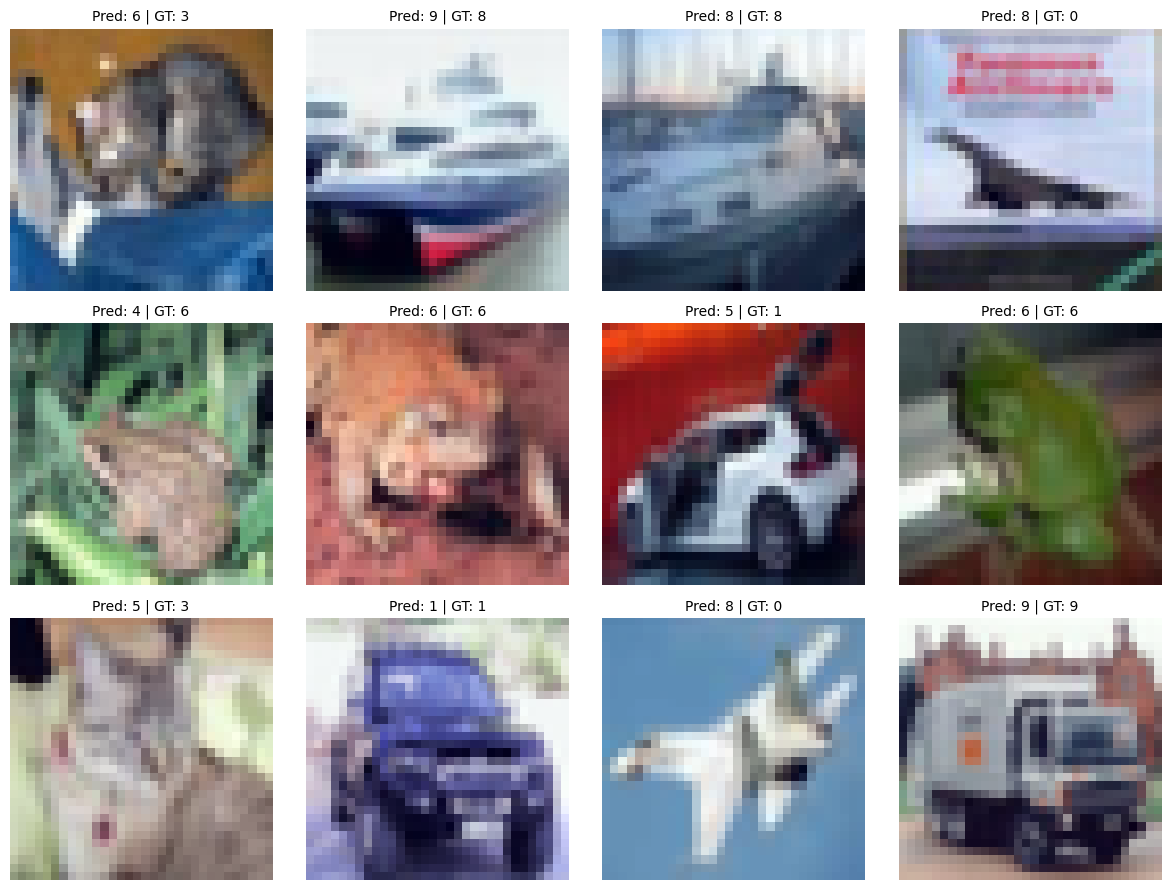

In [12]:
predictions = get_predictions(histories_do["full_unit_dropout"][0]["test_output"])
plot_test_images(X_test, Y_test, predictions)

In [13]:
def compute_accuracy(predictions, Y_test):
    if getattr(Y_test, "ndim", 1) > 1:
        y_true = np.asarray(Y_test).argmax(axis=-1)
    else:
        y_true = np.asarray(Y_test)
    y_pred = np.asarray(predictions)
    return jnp.mean(y_pred == y_true)

In [14]:
predictions_do1 = get_predictions(histories_do["full_unit_dropout"][0])
predictions_ram1 = get_predictions(histories_ram["full_unit_dropout"][0])
predictions_do2 = get_predictions(histories_do["stochastic_depth"][0])
predictions_ram2 = get_predictions(histories_ram["stochastic_depth"][0])
predictions_gd = get_predictions(histories_gd["gd"][0])

In [15]:

print(compute_accuracy(predictions_do1, Y_test))
print(compute_accuracy(predictions_ram1, Y_test))
print(compute_accuracy(predictions_do2, Y_test))
print(compute_accuracy(predictions_ram2, Y_test))
print(compute_accuracy(predictions_gd, Y_test))

0.39429998
0.39609998
0.39769998
0.3937
0.3592


In [16]:
def plot_compare_final_params(
        params_list,
        labels,
        params_init=None,
        n_dims=6,
        particle_idx=-1,
        include_v=True,
        show=True,
    ):
        """Plot and compare final U/V parameters across multiple training runs with optional init overlay.

        Args:
            params_list: list of parameter objects (e.g., [params_do, params_ram, params_gd])
            labels: list of labels for legend (e.g., ['dropout', 'ram', 'gd'])
            params_init: optional initial parameters to overlay as dashed lines
            n_dims: number of dimensions to plot
            particle_idx: which particle to extract
            include_v: whether to plot V parameters
            show: whether to display the plot
        """
        color_map = {
            'independent masks': 'tab:blue',
            'width-shared masks': 'tab:green',
            'depth-shared masks': 'tab:purple',
            'gd': 'black',
        }
        linestyle_map = {
            'dropout': '--',
            'ram': '-',
            'gd': '-',
        }

        # Extract U and V from all params
        param_data = []
        for params in params_list:
            param_data.append((np.asarray(params.U), np.asarray(params.V)))

        U_init, V_init = None, None
        if params_init is not None:
            U_init, V_init = np.asarray(params_init.U), np.asarray(params_init.V)

        L, _, D = param_data[0][0].shape
        n_dims = int(min(n_dims, D))
        layer_idx = np.arange(L)
        selected_dims = np.arange(n_dims)
        n_rows = 2 if include_v else 1
        _fig, axes = plt.subplots(n_rows, n_dims, figsize=(3.6 * n_dims, 3.2 * n_rows), sharex=True, squeeze=False)

        for col, d in enumerate(selected_dims):
            # Plot U
            ax_u = axes[0, col]
            if U_init is not None:
                ax_u.plot(layer_idx, U_init[:, particle_idx, d], color='gray', linewidth=1.0, alpha=0.5, linestyle='--', label='initialization' if col == 0 else None)
            for (u_arr, _), label in zip(param_data, labels):
                label_lower = label.lower()
                color = 'black' if 'gd' in label_lower else color_map.get(next((k for k in color_map if k in label_lower), 'gd'), 'black')
                linestyle = linestyle_map['gd'] if 'gd' in label_lower else linestyle_map['ram' if 'ram' in label_lower else 'dropout']
                ax_u.plot(layer_idx, u_arr[:, particle_idx, d], color=color, linewidth=1.6, linestyle=linestyle, label=label if col == 0 else None)
            ax_u.set_title(f'U (coordinate {d})')#(f'U[:, {particle_idx}, {d}]')
            ax_u.grid(alpha=0.2)
            if col == 0:
                ax_u.set_ylabel('U value')
                ax_u.legend(loc='best', fontsize=8)

            # Plot V
            if include_v:
                ax_v = axes[1, col]
                if V_init is not None:
                    ax_v.plot(layer_idx, V_init[:, particle_idx, d], color='gray', linewidth=1.0, alpha=0.5, linestyle='--', label='initialization' if col == 0 else None)
                for (_, v_arr), label in zip(param_data, labels):
                    label_lower = label.lower()
                    color = 'black' if 'gd' in label_lower else color_map.get(next((k for k in color_map if k in label_lower), 'gd'), 'black')
                    linestyle = linestyle_map['gd'] if 'gd' in label_lower else linestyle_map['ram' if 'ram' in label_lower else 'dropout']
                    ax_v.plot(layer_idx, v_arr[:, particle_idx, d], color=color, linewidth=1.6, linestyle=linestyle, label=label if col == 0 else None)
                ax_v.set_title(f'V (coordinate {d})')#(f'V[:, {particle_idx}, {d}]')
                ax_v.grid(alpha=0.2)
                if col == 0:
                    ax_v.set_ylabel('V value')
                    ax_v.legend(loc='best', fontsize=8)

        for col in range(n_dims):
            axes[-1, col].set_xlabel('layer l')

        _fig.suptitle('U/V comparison across runs', y=1.02)
        _fig.tight_layout()
        if show:
            plt.show()
        return _fig

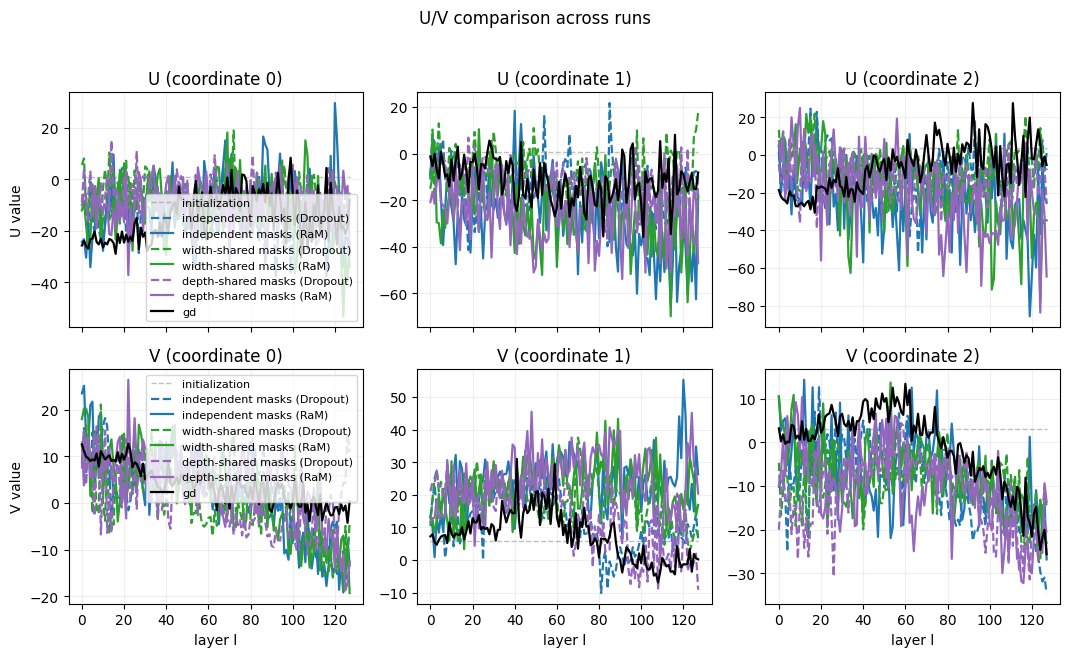

In [18]:
chosen_variant_do1, chosen_variant_ram1 = "full_unit_dropout", "full_unit_dropout"
chosen_variant_do2, chosen_variant_ram2 = "stochastic_depth", "stochastic_depth"
chosen_variant_do3, chosen_variant_ram3 = "single_source_M", "single_source_M"
rep_chosen = 0
comparison_three = plot_compare_final_params(
    [final_params_do[chosen_variant_do1][rep_chosen],
     final_params_ram[chosen_variant_ram1][rep_chosen],
     final_params_do[chosen_variant_do2][rep_chosen],
     final_params_ram[chosen_variant_ram2][rep_chosen],
     final_params_do[chosen_variant_do3][rep_chosen],
     final_params_ram[chosen_variant_ram3][rep_chosen],
     final_params_gd["gd"][rep_chosen]],
    ["independent masks (Dropout)",
     "independent masks (RaM)",
     "width-shared masks (Dropout)",
     "width-shared masks (RaM)",
     "depth-shared masks (Dropout)",
     "depth-shared masks (RaM)",
     "gd"],
    params_init=params0,
    n_dims=3,
    particle_idx=-1,
    include_v=True,
    show=False,
)

In [ ]:
#comparison_three.savefig(f"plots/{DATASET}/new_params_all_variants_N{N}_dataset_{L}M{M}nsteps{n_steps}.pdf")